
# Cancer Drug Prediction
## Project Overview
This project implements a **Quantitative Structure-Activity Relationship (QSAR)** machine learning pipeline capable of predicting the therapeutic potency of chemical compounds against Human Epidermal Growth Factor Receptor (EGFR), a major cancer target. 

EGFR is a transmembrane protein receptor that drives hyper-accelerated cell division in non-small cell lung cancers when mutated or overexpressed. Discovering cancer therapies that bind to and block EGFR traditionally takes years and costs billions in wet labs. This repository builds a high-throughput computational screening tool to predict a molecule's raw therapeutic effectiveness based solely on its chemical layout string.


In [1]:
import logging
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, AllChem
from chembl_webresource_client.new_client import new_client 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# Initiate logging for tracking execution steps
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# Prevent logging if there is no actual WARNING or ERROR
logging.getLogger("urllib3").setLevel(logging.WARNING)
logging.getLogger("chembl_webresource_client").setLevel(logging.WARNING)


## 1. Data Ingestion

This project uses the ChEMBL database API, which contains the world's largest 
manually curated repository of bioactive molecules, managed by the European 
Bioinformatics Institute (EMBL-EBI).

We query the official UniProt accession code for human EGFR (P00533) to 
retrieve bioactivity records for compounds screened against this target, 
filtering to binding assays reporting IC50 in nanomolar units to ensure a 
consistent, comparable potency measurement.


In [3]:
# initialize local python clent (load dictionary map of ChEMBL's available data)
target_client = new_client.target  # target protein dictionaries and biological metadata
activity_client = new_client.activity  # wet lab screening experiments and raw results

# genomic target isolation using global UniProt reference accession code (server maps to its internal chemical registry key)
egfr_target = target_client.filter(target_components__accession='P00533').only('target_chembl_id')
egfr_id = egfr_target[0]['target_chembl_id']
logging.info(f"Human EGFR ChEMBL Database ID: {egfr_id}")

# filter stacking and lazy evaluation
## ChEMBL uses lazy evaluation to record filters and builds an optimized API endpoint URL and prepares to pull only the specific columns we ask via `.only()`
raw_activities = activity_client.filter(
    target_chembl_id=egfr_id,  # limits results to target cancer protein
    assay_type='B',  # isolate 'Binding' assays for drug-protein locks
    standard_type='IC50',  # IC50: concentration needed to inhibit protein by 50%
    standard_units='nM'
).only('molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units')



INFO: Human EGFR ChEMBL Database ID: CHEMBL203


### Chunked retrieval
Given the size of the full EGFR bioactivity dataset, records are streamed in 
batches of 1,000 with a cap of 5,000 total compounds, to keep the dataset 
manageable while retaining sufficient training data.

In [4]:
# Download in chunks with a hard cap of 5000 records to maintian size of data
logging.info("Initiating chunked streaming download from EMBL-EBI servers...")

# Initialize storage and download bounds
records_list = []
batch_size = 1000
start_index = 0

# Iterate through rows using explicit slice indexing to bypass server timeout hangs
while True:
    logging.info(f"Streaming records index range: {start_index} to {start_index + batch_size}...")
    
    # Grab a small, lightweight slice chunk of the data
    chunk = raw_activities[start_index : start_index + batch_size]
    
    # Break the loop if the server runs out of rows
    if not chunk:
        break
        
    records_list.extend(chunk)
    start_index += batch_size
    
    # Cap 5,000 rows to prevent future bottleneck 
    if start_index >= 5000:
        logging.info("Reached optimized portfolio sample limit (5,000 compounds).")
        break

# Compile the array into a raw DataFrame
df_raw = pd.DataFrame.from_records(records_list)
logging.info(f"Raw data download successful. Downloaded volume: {df_raw.shape}")




INFO: Initiating chunked streaming download from EMBL-EBI servers...
INFO: Streaming records index range: 0 to 1000...
INFO: Streaming records index range: 1000 to 2000...
INFO: Streaming records index range: 2000 to 3000...
INFO: Streaming records index range: 3000 to 4000...
INFO: Streaming records index range: 4000 to 5000...
INFO: Reached optimized portfolio sample limit (5,000 compounds).
INFO: Raw data download successful. Downloaded volume: (1080, 6)


### Target Variable Preparation
Raw IC50 values span several orders of magnitude, which skews the distribution 
and makes it difficult for regression models to learn meaningful patterns. 
We convert to pIC50, the $-\log_{10}$ of the molar IC50, which normalizes the 
data into a roughly linear scale. This conversion is the standard convention 
in QSAR literature, where higher pIC50 values represent more potent compounds.

We also remove duplicate SMILES, since the same compound can appear across 
multiple ChEMBL assay records — without deduplication, a single molecule 
could disproportionately influence the model.

In [5]:
# Pipeline Sanitization & Transformation
df_clean = df_raw.dropna(subset=['canonical_smiles', 'standard_value']).copy()
df_clean['standard_value'] = pd.to_numeric(df_clean['standard_value'], errors='coerce')
df_clean = df_clean.dropna(subset=['standard_value'])

# scale raw IC50 value
# raw IC50 is incredibly difficult for ML models to evaluate directly due to exponential skewness
def calculate_pic50(ic50_val):
    if ic50_val <= 0:
        return np.nan
    return 9.0 - math.log10(ic50_val)

df_clean['pIC50'] = df_clean['standard_value'].apply(calculate_pic50)
df_clean = df_clean.dropna(subset=['pIC50'])

# Re-index layout + format column labels
drug_df = df_clean[['molecule_chembl_id', 'canonical_smiles', 'pIC50']].rename(
    columns={'canonical_smiles': 'SMILES', 'molecule_chembl_id': 'ChEMBL_ID'}
).reset_index(drop=True)

# Drop structural duplicates
drug_df = drug_df.drop_duplicates(subset=['SMILES']).reset_index(drop=True)

logging.info(f"Matirx Shape: {drug_df.shape}")
drug_df.head()

INFO: Matirx Shape: (896, 3)


,ChEMBL_ID,SMILES,pIC50
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216
1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551
2,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517
3,CHEMBL306988,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030
4,CHEMBL66879,O=C(O)/C=C/c1ccc(O)cc1,2.522879


## 2. EDA
Now that we have successfully downloaded the data, we will explore the data to ensure that it is ready for model training and testing. To do this, we will check the validity of the SMILES string and the distribution of the pIC50. 

### SMILES Validity

In [6]:
def is_valid(smiles):
    """
    Checks if SMILES can appropriately convert to mols
    Return: True if SMILES can convert to mols else False
    """
    mols = Chem.MolFromSmiles(smiles)  # returns mol or None
    return mols is not None  # common idiom for RDKit tutorials

drug_df['valid smiles'] = drug_df['SMILES'].apply(is_valid)  # add validity col for SMILES
num_invalid = (~drug_df['valid smiles']).sum()  # get the sum of FALSE in 'valid smiles' col
logging.info(f"{num_invalid}/{len(drug_df)} invalid SMILES found")

INFO: 0/896 invalid SMILES found


### pIC50 Distribution
To view the pIC50 distribution, we will create a histogram and a boxplot. The histogram will show us the shape of the distribution, while the boxplot will show spread and outliers. 

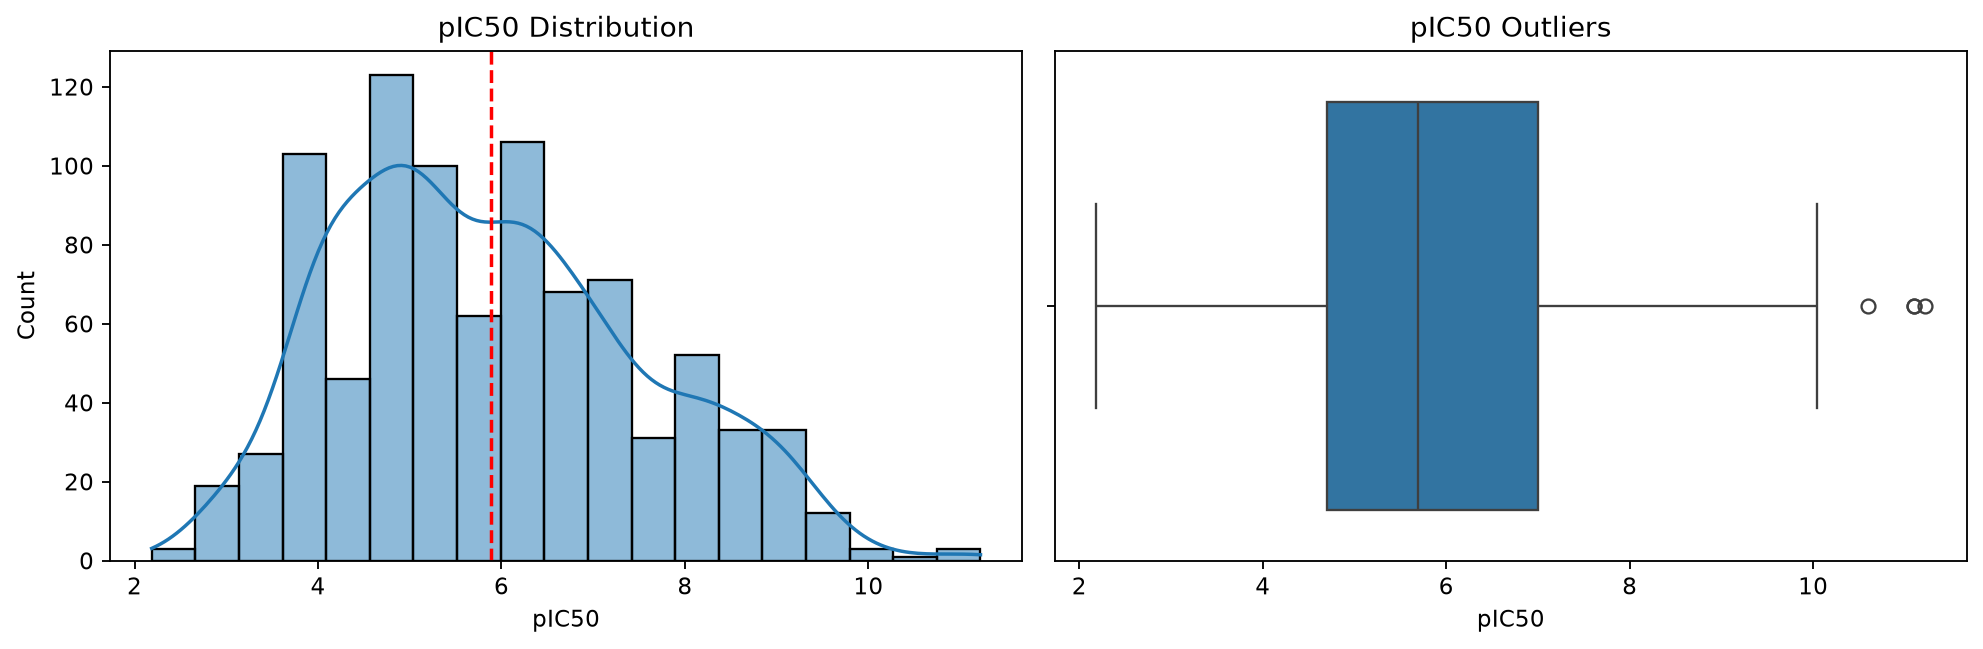

INFO: pIC50 range: 2.19 - 11.22
INFO: pIC50 median: 5.69
INFO: Average pIC50: 5.89


In [7]:
# Initialize matplotlib and seaborn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Create histogram to see distribution
sns.histplot(drug_df['pIC50'], kde=True, ax=axes[0])
axes[0].set_title('pIC50 Distribution')
axes[0].axvline(drug_df['pIC50'].mean(), color='red', linestyle='--')

# Create boxplot to see spread 
sns.boxplot(x=drug_df['pIC50'], ax=axes[1])
axes[1].set_title('pIC50 Outliers')
plt.tight_layout()
plt.show()

pIC50 = drug_df['pIC50']
pIC50_min = pIC50.min()
pIC50_max = pIC50.max()
pIC50_mean = pIC50.mean()
pIC50_median = pIC50.median()

logging.info(f"pIC50 range: {pIC50_min:.2f} - {pIC50_max:.2f}")
logging.info(f"pIC50 median: {pIC50_median:.2f}")
logging.info(f"Average pIC50: {pIC50_mean:.2f}")


From the histogram, we can see the data is only slightly right-skewed, with a mean of 5.89, slightly higher than the median of 5.69. The boxplot confirms this by showing the median closer to the lower edge of the interquartile range. A few outliers are also shown as compounds above the upper whisker, all falling on the high-potency end, with no corresponding low-end outliers. Because this indicates unusually potent compounds rather than random noise, they are likely genuine high-affinity inhibitors rather than data errors; therefore, they should be retained in the dataset for modeling rather than removed.

## 3. Featurization
As machine learning models require numeric input, and SMILES strings encode molecular structure **symbolically** rather than numerically, we generate complementary featrures to translate each molecule into a format the model can learn from. Common approaches include RDKit molecular descriptors and Morgan fingerprints. RDKit molecular descriptors are interpretable physiochemical properties, such as molecular weight and LogP, several of which correspond to Lipinski's Rule of Five for drug-likeness. Morgan fingerprints are bit-vector encodings of local substructural patterns, generated by algorithmically walking each atom's bonded neighborhood out to a fixed radius. The descriptors provide interpretability, while the fingerprints provide structural resolution. Using both feature types allows the model to draw on well-established drug-likeness properties alongside finer-grained structural detail that descriptors alone would not capture. 

In [8]:
def compute_descriptors(smiles):
    """Generate complementary descriptor features from SMILES"""
    mol = Chem.MolFromSmiles(smiles)
    return pd.Series({
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'NumHDonors': Lipinski.NumHDonors(mol),
        'NumHAcceptors': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol)
    })

descriptor_df = drug_df['SMILES'].apply(compute_descriptors)  # apply function to smiles to generate a df
drug_df = pd.concat([drug_df, descriptor_df], axis=1)  # combine dfs 

logging.info(f"Descriptor shape: {descriptor_df.shape}")

INFO: Descriptor shape: (896, 7)


In [9]:
def compute_morgan_fp(smiles, radius=2, n_bits=1024):
    """Generate Morgan Fingerprints from SMILES"""
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

fp_array = np.array([compute_morgan_fp(smiles) for smiles in drug_df['SMILES']])
fp_df = pd.DataFrame(fp_array, columns=[f'FP_{i}' for i in range(fp_array.shape[1])])
drug_df = pd.concat([drug_df, fp_df], axis=1)  # combine dfs

logging.info(f"FP shape: {fp_df.shape}")

[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerator
[19:13:07] DEPRECATION WARNING: please use MorganGenerat

## 4. Split Data
Now that we have successfully added the descriptor and morgan fingerprint columns, we can split the data into training and testing sets for model training. The split ratio we will use will be 80:20.

In [10]:
# define features and target cols
feature_cols = list(descriptor_df.columns) + list(fp_df.columns)
X = drug_df[feature_cols]
y = drug_df['pIC50']

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

logging.info(f"Train data set: {X_train.shape[0]}")
logging.info(f"Test data set: {X_test.shape[0]}")

INFO: Train data set: 716
INFO: Test data set: 180


## 5. Model Training
To train the model, we will be using Random Fores, as it is a standard option for QSAR, along with Gradient Boosting. These methods can appropriately handle the mix of continuous descriptors and binary bits as well without the need for feature scaling. 

In [11]:
random_forest = RandomForestRegressor(n_estimators=500, random_state=24, n_jobs=-1)
random_forest.fit(X_train, y_train)

y_predict = random_forest.predict(X_test)

## 6. Evaluation
To evaluate the model, we will be examining the R2

In [15]:
r2 = r2_score(y_test, y_predict)
rmse = mean_squared_error(y_test, y_predict)
logging.info(f"R2: {r2:.2f}")
logging.info(f"RMSE: {rmse:.2f}")

INFO: R2: 0.71
INFO: RMSE: 0.73


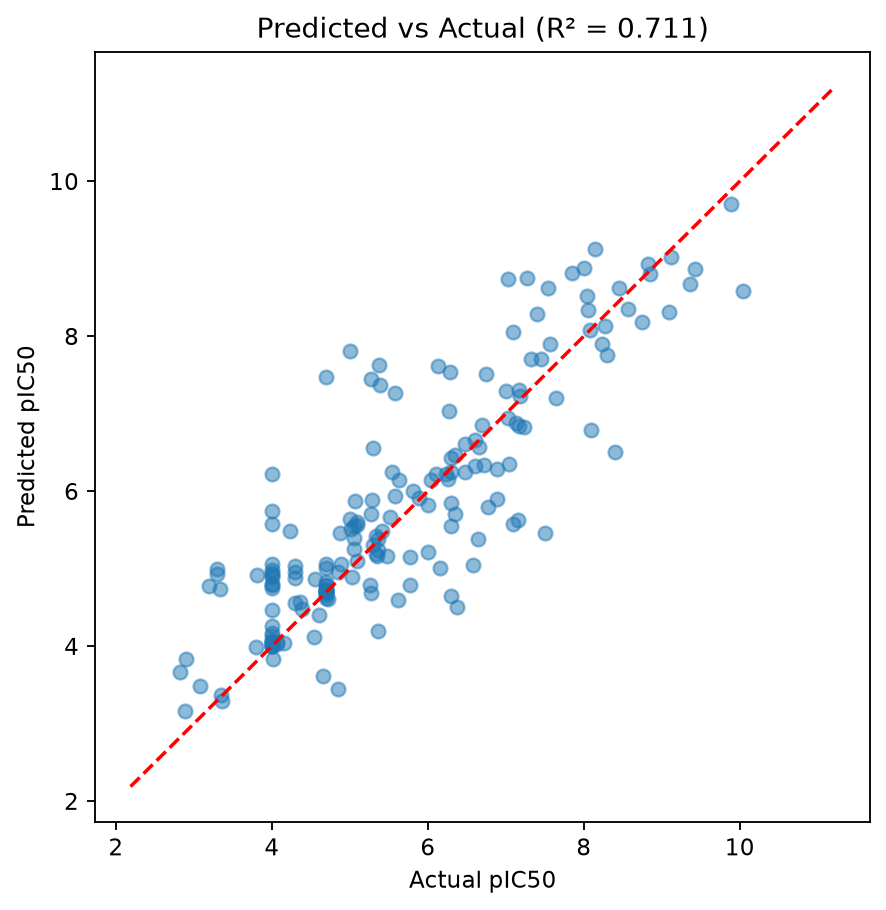

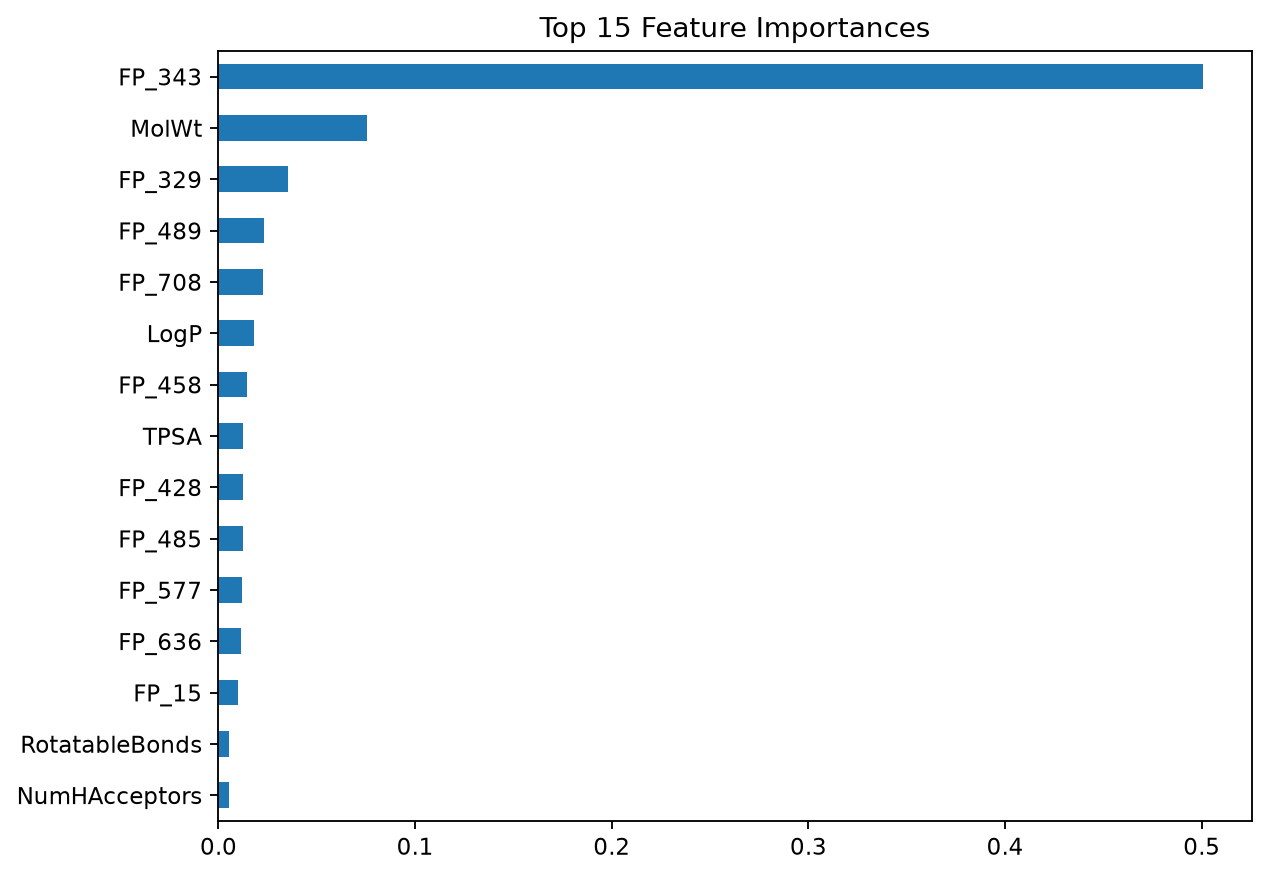

In [ ]:
# Predicted vs actual scatter — the standard QSAR diagnostic plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_predict, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'Predicted vs Actual (R² = {r2:.3f})')
plt.show()

# Feature importance
importances = pd.Series(random_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()